<a href="https://colab.research.google.com/github/AleksiOikarinen/Schoolwork-New/blob/main/Data_Analyysi_Projekti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/content/Movie_Data_File.csv")

df = df.drop(columns=["Release_year"])
df = df.drop(columns=["Owner_rating"])
sampled_df = df.sample(n=200, random_state=42)
print('Rivien ja sarakkeiden määrä:', df.shape)

Rivien ja sarakkeiden määrä: (10002, 27)


Poistimme tuotanto vuodet sillä ne olivat NaN. Owner rating ei myöskään tarjonnut mitään kiinostavaa tietoa. Totesimme myös että visualisoinnissa 10000 merkkiä on vaikea lukea joten päätimme ottaa 200 satunnaista elokuvaa

In [4]:
print(df.isna().sum())
df = df.drop_duplicates()
df.sample(5)


Film_title             0
Director              10
Cast                  57
Average_rating       581
Genres                24
Runtime               10
Countries            118
Original_language      3
Spoken_languages       3
Description            2
Studios              307
Watches                0
List_appearances       0
Likes                  0
Fans                   0
½                      0
★                      0
★½                     0
★★                     0
★★½                    0
★★★                    0
★★★½                   0
★★★★                   0
★★★★½                  0
★★★★★                  0
Total_ratings          0
Film_URL               0
dtype: int64


,Film_title,Director,Cast,Average_rating,Genres,Runtime,Countries,Original_language,Spoken_languages,Description,...,★½,★★,★★½,★★★,★★★½,★★★★,★★★★½,★★★★★,Total_ratings,Film_URL
743,How the Grinch Stole Christmas,Ron Howard,"['Jim Carrey', 'Taylor Momsen', 'Jeffrey Tambo...",3.53,"['Family', 'Comedy', 'Fantasy']",104.0,"['Germany', 'USA']",English,['English'],The Grinch decides to rob Whoville of Christma...,...,11572,44609,48004,154450,122564,175184,42282,140369,757727,https://letterboxd.com/film/how-the-grinch-sto...
4955,Ong Bak,Prachya Pinkaew,"['Tony Jaa', 'Petchtai Wongkamlao', 'Patrarin ...",3.58,"['Action', 'Adventure', 'Thriller', 'Crime']",105.0,"['France', 'Hong Kong', 'Thailand']",Thai,"['Thai', 'English']",When the head of a statue sacred to a village ...,...,269,1138,1999,7451,9337,9638,1816,2283,34213,https://letterboxd.com/film/ong-bak/
4496,Never Let Go,John Guillermin,"['Richard Todd', 'Peter Sellers', 'Elizabeth S...",3.49,"['Crime', 'Thriller']",90.0,['UK'],English,['English'],"John Cummings, an unsuccessful cosmetics sales...",...,12,35,72,301,358,343,59,38,1224,https://letterboxd.com/film/never-let-go/
5401,Operation Leopard,Raoul Coutard,"['Bruno Cremer', 'Mimsy Farmer', 'Jacques Perr...",NaN,['War'],96.0,['France'],French,['French'],"In May 1978, the mining town of Kolwezi in Kat...",...,7,15,40,45,17,12,1,2,157,https://letterboxd.com/film/operation-leopard/
2873,Black or White,Mike Binder,"['Kevin Costner', 'Jillian Estell', 'Jennifer ...",3.01,['Drama'],121.0,['USA'],English,['English'],A grieving widower is drawn into a custody bat...,...,144,468,675,1206,608,491,79,158,3990,https://letterboxd.com/film/black-or-white/


Ensin printtasimme kuinka monta tulosta on NaN jonka jälkeen poistamme kaikki toistuvat arvot. sitten sampleemme 5 satunnaista elokuvaa että lukeminen on helpompaa.

<Figure size 1000x600 with 0 Axes>

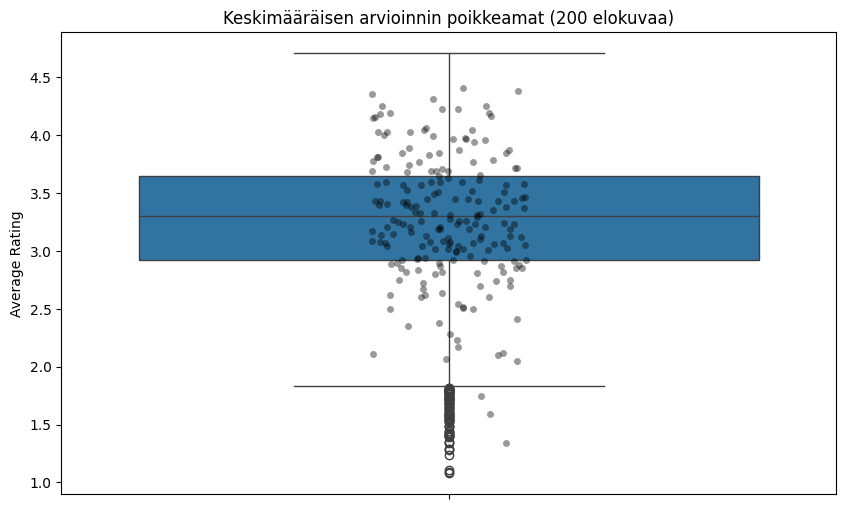

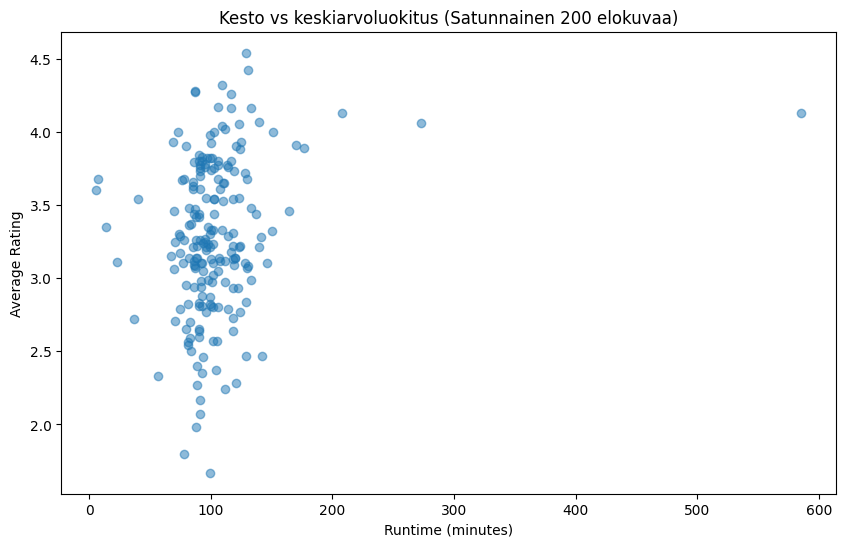

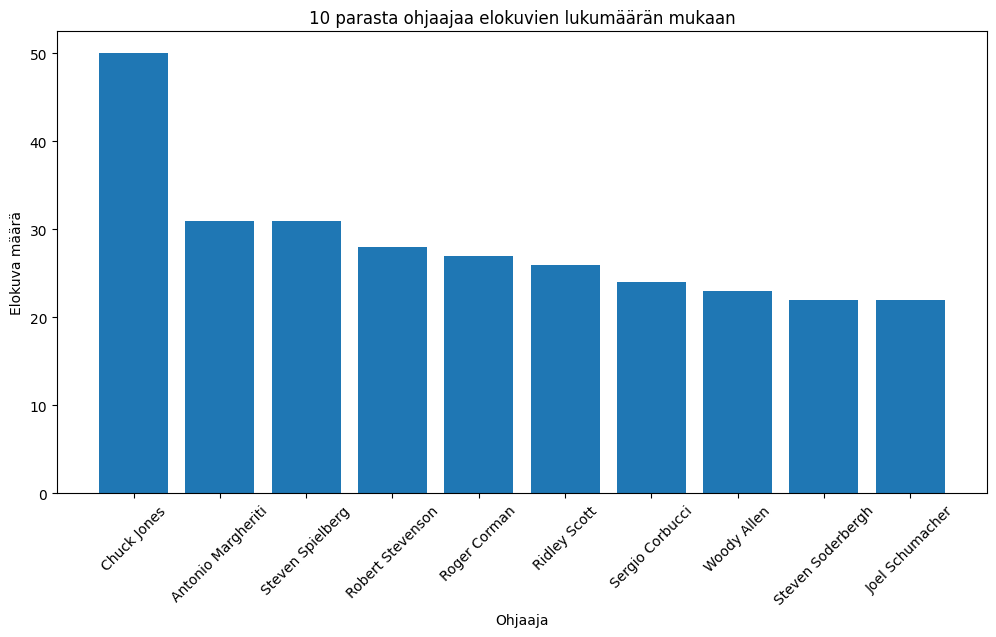

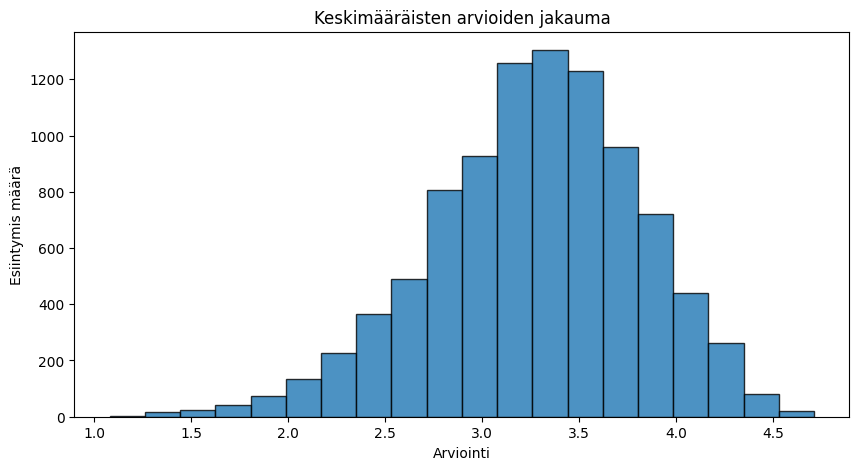

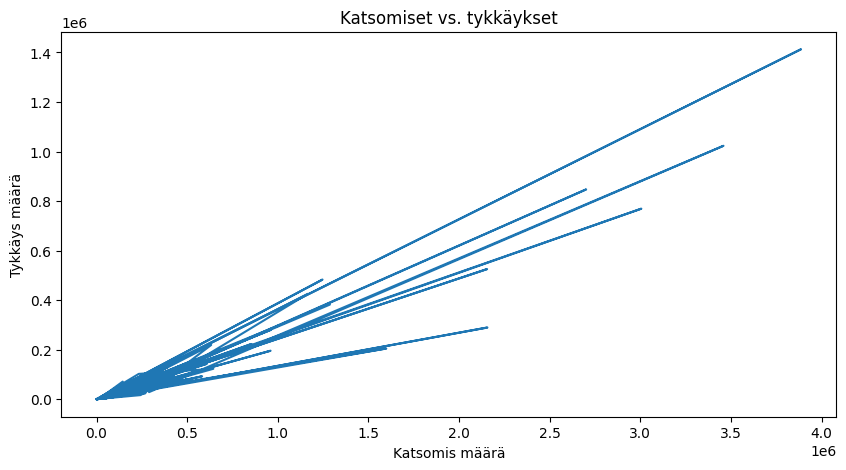

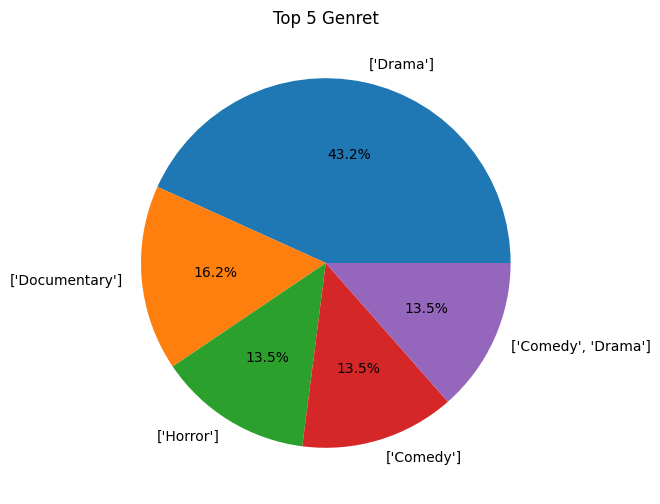

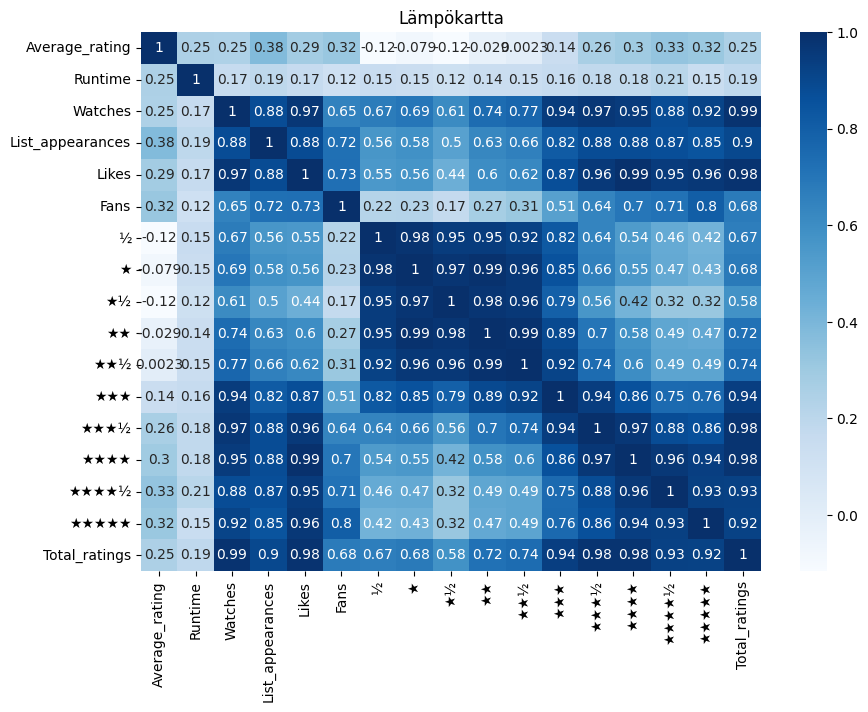

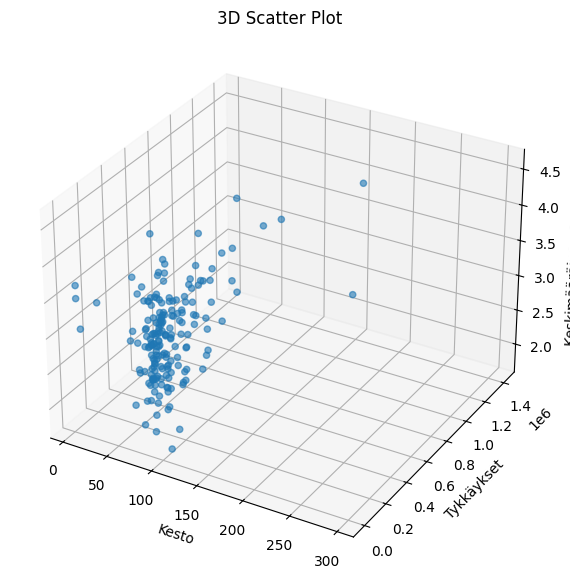

In [9]:

df['Director'] = df['Director'].fillna("Unknown")
df = df.dropna(subset=['Average_rating'])

df["Rating_bin"] = pd.qcut(
    df["Average_rating"],
    q=4,
    labels=["Low", "Below Average", "Above Average", "High"]
)


plt.figure(figsize=(10, 6))

sample = df['Average_rating'].sample(200)

#Testi

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Average_rating'])
sns.stripplot(y=sample, color="black", alpha=0.4)
plt.title("Keskimääräisen arvioinnin poikkeamat (200 elokuvaa)")
plt.ylabel("Keskimääräinen arvosana")
plt.show()


#Scatter plot
sample = df.sample(200)

plt.figure(figsize=(10, 6))
plt.scatter(sample["Runtime"], sample["Average_rating"], alpha=0.5)

plt.title("Kesto vs keskiarvoluokitus (Satunnainen 200 elokuvaa)")
plt.xlabel("Kesto (minuutteina)")
plt.ylabel("Keskimääräinen arvosana")
plt.show()


#Bar chart
plt.figure(figsize=(12,6))
top_directors = df['Director'].value_counts().head(10)

plt.bar(top_directors.index, top_directors.values)
plt.title("10 suurinta ohjaajaa elokuvien lukumäärän mukaan")
plt.xlabel("Ohjaaja")
plt.ylabel("Elokuva määrä")
plt.xticks(rotation=45)
plt.show()


#Histogram
plt.figure(figsize=(10,5))
plt.hist(df["Average_rating"], bins=20, edgecolor="black",linewidth=1,alpha=0.8)

plt.title("Keskimääräisten arvioiden jakauma")
plt.xlabel("Arviointi")
plt.ylabel("Esiintymis määrä")
plt.show()

#Line plot
plt.figure(figsize=(10,5))
plt.plot(sampled_df["Watches"], sampled_df["Likes"])
plt.title("Katsomiset vs. tykkäykset")
plt.xlabel("Katsomis määrä")
plt.ylabel("Tykkäys määrä")
plt.show()

#Pie chart
genre_counts = sampled_df["Genres"].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(genre_counts, labels=genre_counts.index, autopct="%1.1f%%")
plt.title("Top 5 Genret")
plt.show()

#Heatmap
numeric_df = sampled_df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Lämpökartta")
plt.show()

#3D plot

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(sampled_df["Runtime"], sampled_df["Likes"], sampled_df["Average_rating"], alpha=0.6)

ax.set_xlabel("Kesto")
ax.set_ylabel("Tykkäykset")
ax.set_zlabel("Keskimääräinen arvosana")
plt.title("3D Scatter Plot")
plt.show()


Tässä yritimme muuta tapaa kuin poistaa kaikki NaN arvot director kohdassa korvaamalla ne Unknownilla. sitten poistamme Avarage_rating arvot jos ne puuttuivat. jonka jälkeen teimme binnauksen. jonka jälkeen siirryimme visualisoimaan 200 satunnaista elokuvaa sillä 10000 pistettä visualisoinnissa oli aika hankalaa lukea tai ymmärtää.

In [6]:
#Binnaus

print("\nHead with Rating_bin:")
print(df[["Average_rating", "Rating_bin"]].head())

print("\nValue counts for bins:")
print(df["Rating_bin"].value_counts())



Head with Rating_bin:
   Average_rating     Rating_bin
0            3.57  Above Average
1            4.18           High
2            3.93           High
3            3.79           High
4            4.28           High

Value counts for bins:
Rating_bin
Below Average    2389
Low              2349
High             2339
Above Average    2315
Name: count, dtype: int64


Tässä kohdassa otamme aikaisemman binnauksen käyttöön ja printtaamme sen tuloksen.

In [7]:
#Attribute types

ordinal_columns = ["Rating_bin"]
types = {
    "Nominaali": [],
    "Ordinaali": [],
    "Binaari": []
}
for col in df.columns:
  unique_vals = df[col].dropna().unique()
  n_unique = len(unique_vals)
  dtype = df[col].dtype

  if col in ordinal_columns:
    types["Ordinaali"].append(col)

  elif n_unique == 2:
    types["Binaari"].append(col)

  elif dtype == "object":
    types["Nominaali"].append(col)

print("Nominaalit:", types["Nominaali"])
print("Ordinaalit:", types["Ordinaali"])
print("Binaarit:", types["Binaari"])

Nominaalit: ['Film_title', 'Director', 'Cast', 'Genres', 'Countries', 'Original_language', 'Spoken_languages', 'Description', 'Studios', 'Film_URL']
Ordinaalit: ['Rating_bin']
Binaarit: []


Tässä kohdassa erottelemme kaikki käytetyt arvot niidenkuuluville atribuuteille. totesimme että 10/11 atribuuteistamme ovat Nominaaleja ja vain yksi on Ordinaali. Ajattelimme että vain Original_language voisi mahdollisesti olla Binaari jos se olisi kysymys että onko elokuva käännetty vai alkuperäiskielellään.

In [8]:
#Max rating
Highest_rating = np.max(df['Average_rating'])
print('Highest rating:', Highest_rating)

#Min rating
Lowest_rating = np.min(df['Average_rating'])
print('Lowest rating:', Lowest_rating)

#Laske sarakkeiden keskiarvot ja mediaaniarvot
mean_rating = np.mean(df['Average_rating'])
print('The mean rating of Average_rating:', mean_rating)

median_rating = np.median(df['Average_rating'])
print('The median rating of Average_rating:', median_rating)

#laskee datan keskihajonnan ja varianssin
std_dev_rating = np.std(df['Average_rating'], ddof = 1)
print("The sample standard deviation of Average_rating:", std_dev_rating)

variance_rating = np.var(df['Average_rating'])
print("The variance of Average_rating:", variance_rating)

#laskee datan summan ja tulon
sum_watches = np.sum(df['Watches'])
print("Total amount of watches across all of the movies:", sum_watches)

Highest rating: 4.71
Lowest rating: 1.08
The mean rating of Average_rating: 3.2691620528109024
The median rating of Average_rating: 3.3
The sample standard deviation of Average_rating: 0.5418558510543807
The variance of Average_rating: 0.29357650184791895
Total amount of watches across all of the movies: 1700211170


Lopuksi käytimme kaikkia annettuja NumPy koodeja josta emme saaneet kauhestai kiinnostavaa tietoa muuta kuin kokonais katsoja määrän joka oli runsaat 1.7 miljardia, sekä Korkeimmain ja alimman ratingin